
# CardioIA — Fase 2 · Parte 2: classificador de risco com TF-IDF

Objetivo: classificar frases de sintomas como **alto risco** ou **baixo risco**, simulando uma triagem automatizada.

Pipeline (Cap. 11, NLP estatístico): base rotulada → pré-processamento → **TF-IDF** → modelos do scikit-learn → avaliação (acurácia, recall, matriz de confusão) → teste com frases novas → **análise de distorções e vieses** (Cap. 7, IA responsável).

> Material educacional. Os rótulos são simulados e o modelo não deve ser usado para triagem real.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from pathlib import Path

try:
    STOPWORDS_PT = stopwords.words("portuguese")
except LookupError:
    import nltk
    nltk.download("stopwords", quiet=True)
    STOPWORDS_PT = stopwords.words("portuguese")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SEMENTE = 42
ALTO = "alto risco"
pd.set_option("display.max_colwidth", None)


## 1. Base de dados

[`data/frases_risco.csv`](../data/frases_risco.csv) tem as colunas `frase`, `situacao` e `origem`:

* **manual** (120 frases): relatos escritos pela equipe, 60 de alto e 60 de baixo risco, com linguagem coloquial, negações e casos "pegadinha" (como *dor no peito quando aperto o local depois do supino*);
* **fase1** (80 frases): geradas a partir do dataset simulado da Fase 1 por [`tools/gerar_base_risco.py`](../tools/gerar_base_risco.py). O rótulo vem de `rotulo_risco_cardiovascular_simulado`, e cada frase descreve sexo, faixa etária, sintomas e fatores de risco do caso.

In [2]:
df = pd.read_csv(RAIZ / "data" / "frases_risco.csv")
print(df.shape)
df.sample(8, random_state=SEMENTE)

(200, 3)


,frase,situacao,origem
95,tenho rinite e o nariz escorre,baixo risco,manual
15,"Homem de meia-idade relata nenhum sintoma no momento, com diabetes, histórico de doença cardíaca.",baixo risco,fase1
30,"Paciente mulher idosa refere dor no peito em pressão, com diabetes.",baixo risco,fase1
158,"Paciente mulher idosa refere dor no peito em pressão, com pressão 149 por 67, tabagismo.",baixo risco,fase1
128,tive dor no peito e desmaiei por alguns segundos,alto risco,manual
115,estou com alergia e espirros pela manhã,baixo risco,manual
69,minha pressão está 200 por 120 e estou com dor de cabeça muito forte,alto risco,manual
170,tenho um pouco de dor de barriga depois do almoço,baixo risco,manual


In [3]:
pd.crosstab(df["origem"], df["situacao"], margins=True)

situacao,alto risco,baixo risco,All
origem,,,
fase1,32,48,80
manual,60,60,120
All,92,108,200


In [4]:
df["n_palavras"] = df["frase"].str.split().str.len()
df.groupby(["origem", "situacao"])["n_palavras"].describe()[["mean", "min", "max"]].round(1)

mean   min   max
origem situacao                     
fase1  alto risco   20.3  13.0  28.0
       baixo risco  14.6   7.0  21.0
manual alto risco   11.4   8.0  15.0
       baixo risco   9.1   5.0  15.0


## 2. Pré-processamento

* minúsculas;
* remoção de *stopwords* do NLTK, **exceto** `não`, `nem` e `sem`. A lista padrão apaga essas palavras, e então "não sinto dor no peito" ficaria igual a "sinto dor no peito";
* unigramas e bigramas (`ngram_range=(1, 2)`) para capturar expressões como "dor peito" e "falta ar".

In [5]:
NEGACOES = {"não", "nem", "sem"}
STOPWORDS = [w for w in STOPWORDS_PT if w not in NEGACOES]
TOKEN = r"(?u)\b[\w-]+\b"

def criar_tfidf(preprocessor=None):
    return TfidfVectorizer(lowercase=True, preprocessor=preprocessor, stop_words=STOPWORDS,
                           ngram_range=(1, 2), sublinear_tf=True, token_pattern=TOKEN)

print("'não' removido pela lista padrão?", "não" in STOPWORDS_PT)
print("'não' removido pela nossa lista?  ", "não" in STOPWORDS)

'não' removido pela lista padrão? True
'não' removido pela nossa lista?   False



## 3. Treino e teste

Divisão **75% / 25% estratificada** pela classe, com semente fixa para reprodutibilidade.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["frase"], df["situacao"], test_size=0.25, stratify=df["situacao"], random_state=SEMENTE)
print(f"treino: {len(X_train)} | teste: {len(X_test)}")
print(y_test.value_counts().to_dict())

treino: 150 | teste: 50
{'baixo risco': 27, 'alto risco': 23}



## 4. TF-IDF: de frases para vetores

O TF-IDF dá peso alto a termos frequentes **na frase** e raros **no conjunto**. O vetorizador é ajustado somente no treino, para evitar vazamento de informação do teste.

In [7]:
tfidf = criar_tfidf()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
print("Matriz de treino:", X_train_vec.shape, "(frases x termos)")
print(f"Esparsidade: {1 - X_train_vec.nnz / np.prod(X_train_vec.shape):.1%} de zeros")

exemplo = X_train.iloc[0]
vetor = X_train_vec[0].toarray().ravel()
termos = tfidf.get_feature_names_out()
print("\nFrase:", exemplo)
pd.Series(vetor, index=termos).loc[lambda s: s > 0].sort_values(ascending=False).round(3).head(10)

Matriz de treino: (150, 919) (frases x termos)
Esparsidade: 98.3% de zeros

Frase: meu coração está disparado há horas e sinto tontura forte


coração disparado    0.330
disparado            0.330
disparado horas      0.330
tontura forte        0.330
horas                0.330
horas sinto          0.330
sinto tontura        0.330
tontura              0.274
forte                0.274
coração              0.231
dtype: float64

In [8]:
idf = pd.Series(tfidf.idf_, index=termos)
pd.DataFrame({"termos mais comuns (IDF baixo)": idf.nsmallest(10).index,
              "termos mais raros (IDF alto)": idf.nlargest(10).index})

,termos mais comuns (IDF baixo),termos mais raros (IDF alto)
0,peito,140 70
1,dor,140 73
2,pressão,140 82
3,dor peito,141
4,mulher,141 87
5,relata,142
6,homem,142 78
7,peito pressão,143
8,sedentarismo,143 81
9,cardiopatia,144



## 5. Comparação de modelos

Três classificadores clássicos, cada um em um `Pipeline` com o TF-IDF:

* **Regressão Logística** (`class_weight="balanced"`): linear e interpretável;
* **Árvore de Decisão**: regras do tipo "se contém termo X…";
* **Naive Bayes Multinomial**: modelo clássico para texto, visto no Cap. 11.

Em triagem, **deixar passar um alto risco** (falso negativo) é mais grave que um alarme falso. Por isso, além da acurácia, acompanhamos o **recall da classe alto risco**. Como a base é pequena, também usamos validação cruzada de 5 dobras.

In [9]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEMENTE),
    "Naive Bayes": MultinomialNB(),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
linhas, pipelines = [], {}
for nome, modelo in modelos.items():
    pipe = make_pipeline(criar_tfidf(), modelo).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    cv_acc = cross_val_score(make_pipeline(criar_tfidf(), modelo), df["frase"], df["situacao"], cv=cv)
    pipelines[nome] = pipe
    linhas.append({
        "modelo": nome,
        "acurácia (teste)": accuracy_score(y_test, pred),
        "recall alto risco": recall_score(y_test, pred, pos_label=ALTO),
        "precisão alto risco": precision_score(y_test, pred, pos_label=ALTO),
        "F1 alto risco": f1_score(y_test, pred, pos_label=ALTO),
        "acurácia CV (média)": cv_acc.mean(),
        "acurácia CV (desvio)": cv_acc.std(),
    })
comparacao = pd.DataFrame(linhas).set_index("modelo").round(3)
comparacao

,acurácia (teste),recall alto risco,precisão alto risco,F1 alto risco,acurácia CV (média),acurácia CV (desvio)
modelo,,,,,,
Regressão Logística,0.78,0.870,0.714,0.784,0.700,0.087
Árvore de Decisão,0.80,0.696,0.842,0.762,0.725,0.035
Naive Bayes,0.78,0.783,0.750,0.766,0.640,0.058


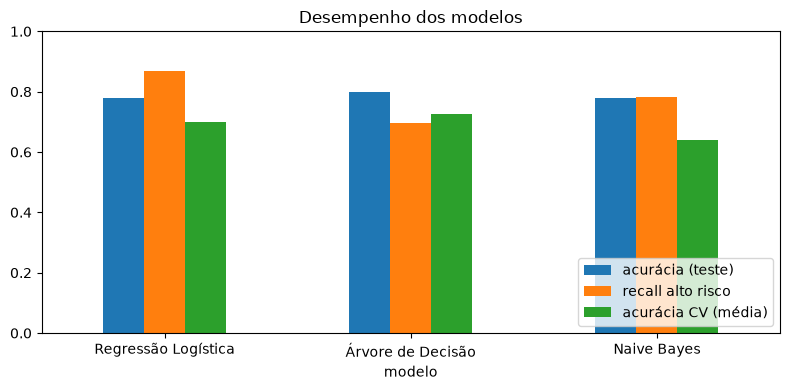

In [10]:
ax = comparacao[["acurácia (teste)", "recall alto risco", "acurácia CV (média)"]].plot.bar(figsize=(8, 4), rot=0)
ax.set_ylim(0, 1)
ax.set_title("Desempenho dos modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6. Modelo escolhido: Regressão Logística

Escolhemos a Regressão Logística porque ela tem o maior recall de alto risco, uma acurácia equivalente à dos outros modelos e **coeficientes interpretáveis**, que mostram quais termos empurram a decisão para cada classe.

Acurácia no teste: 78.0%

              precision    recall  f1-score   support

  alto risco      0.714     0.870     0.784        23
 baixo risco      0.864     0.704     0.776        27

    accuracy                          0.780        50
   macro avg      0.789     0.787     0.780        50
weighted avg      0.795     0.780     0.780        50



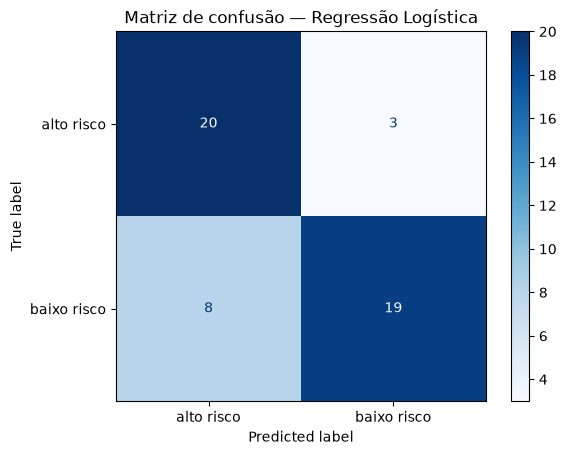

In [11]:
modelo = pipelines["Regressão Logística"]
y_pred = modelo.predict(X_test)
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.1%}\n")
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[ALTO, "baixo risco"], cmap="Blues")
plt.title("Matriz de confusão — Regressão Logística")
plt.show()

In [12]:
vet = modelo.named_steps["tfidfvectorizer"]
clf = modelo.named_steps["logisticregression"]
# classes_ = ['alto risco', 'baixo risco'] -> coeficiente positivo puxa para 'baixo risco'
coef = pd.Series(clf.coef_[0], index=vet.get_feature_names_out())
pd.DataFrame({
    "termos que indicam ALTO risco": coef.nsmallest(15).index,
    "peso (alto)": coef.nsmallest(15).values.round(2),
    "termos que indicam BAIXO risco": coef.nlargest(15).index,
    "peso (baixo)": coef.nlargest(15).values.round(2),
})

,termos que indicam ALTO risco,peso (alto),termos que indicam BAIXO risco,peso (baixo)
0,peito,-0.68,meia-idade,0.82
1,ar,-0.64,leve,0.77
2,dor peito,-0.54,homem meia-idade,0.72
3,cansaço pressão,-0.51,meia-idade procurou,0.61
4,falta,-0.46,relata,0.58
5,falta ar,-0.46,momento,0.49
6,pressão,-0.40,nenhum,0.49
7,família sedentarismo,-0.39,nenhum sintoma,0.49
8,desmaiei,-0.36,sintoma,0.49
9,refere queimação,-0.36,sintoma momento,0.49


In [13]:
erros = pd.DataFrame({"frase": X_test, "real": y_test, "previsto": y_pred,
                      "prob. alto risco": modelo.predict_proba(X_test)[:, 0].round(2)})
erros[erros["real"] != erros["previsto"]].sort_values("real")

,frase,real,previsto,prob. alto risco
162,"Paciente mulher idosa refere aperto no peito, com pressão 183 por 96, diabetes, sedentarismo.",alto risco,baixo risco,0.50
69,minha pressão está 200 por 120 e estou com dor de cabeça muito forte,alto risco,baixo risco,0.46
36,"Homem idoso relata queimação no peito, cansaço, com pressão 165 por 87, tabagismo, alteração ST-T no ECG.",alto risco,baixo risco,0.49
82,dor no joelho quando subo escadas,baixo risco,alto risco,0.51
48,minha pressão estava 12 por 8 na farmácia,baixo risco,alto risco,0.57
142,"Paciente homem de meia-idade refere aperto no peito, falta de ar, com pressão 145 por 73, colesterol alto.",baixo risco,alto risco,0.58
192,senti uma fisgada nas costelas ao virar o corpo,baixo risco,alto risco,0.55
17,tive uma câimbra na panturrilha durante a noite,baixo risco,alto risco,0.55
56,"não tenho dor no peito nem falta de ar, só um resfriado",baixo risco,alto risco,0.67
199,minha frequência cardíaca no relógio deu 72 em repouso,baixo risco,alto risco,0.56



## 7. Comportamento diante de frases novas

Frases que **não estão na base**, com níveis de risco diferentes, linguagem informal, negação e ambiguidade.

In [14]:
novas = pd.DataFrame([
    ("sinto um aperto no peito que vai para o braço e estou suando frio", ALTO, "clássica"),
    ("desmaiei hoje cedo e meu coração está muito acelerado", ALTO, "clássica"),
    ("tô com o peito doendo e sem fôlego", ALTO, "informal"),
    ("meu peito tá esquisito e pesado desde cedo", ALTO, "informal"),
    ("estou com um pouco de coriza e espirros", "baixo risco", "clássica"),
    ("tive dor no braço depois de pintar a parede", "baixo risco", "clássica"),
    ("não sinto dor no peito nem falta de ar", "baixo risco", "negação"),
    ("não tenho falta de ar, só uma dor leve nas costas", "baixo risco", "negação"),
    ("estou com um aperto no coração de saudade da família", "baixo risco", "ambígua"),
    ("dor no peito", ALTO, "curta"),
], columns=["frase", "esperado", "tipo"])
novas["prob. alto risco"] = modelo.predict_proba(novas["frase"])[:, 0].round(2)
novas["previsto"] = modelo.predict(novas["frase"])
novas["acertou"] = np.where(novas["previsto"] == novas["esperado"], "✔", "✘")
novas

,frase,esperado,tipo,prob. alto risco,previsto,acertou
0,sinto um aperto no peito que vai para o braço e estou suando frio,alto risco,clássica,0.55,alto risco,✔
1,desmaiei hoje cedo e meu coração está muito acelerado,alto risco,clássica,0.59,alto risco,✔
2,tô com o peito doendo e sem fôlego,alto risco,informal,0.58,alto risco,✔
3,meu peito tá esquisito e pesado desde cedo,alto risco,informal,0.58,alto risco,✔
4,estou com um pouco de coriza e espirros,baixo risco,clássica,0.39,baixo risco,✔
5,tive dor no braço depois de pintar a parede,baixo risco,clássica,0.48,baixo risco,✔
6,não sinto dor no peito nem falta de ar,baixo risco,negação,0.65,alto risco,✘
7,"não tenho falta de ar, só uma dor leve nas costas",baixo risco,negação,0.57,alto risco,✘
8,estou com um aperto no coração de saudade da família,baixo risco,ambígua,0.54,alto risco,✘
9,dor no peito,alto risco,curta,0.66,alto risco,✔



## 8. Distorções e vieses

Seguindo o roteiro do Cap. 7 (fairness), investigamos quatro pontos:

1. **Desempenho por origem dos dados**: o modelo funciona igual para frases manuais e para frases derivadas da Fase 1?
2. **Atributos sensíveis**: as frases da Fase 1 mencionam sexo e faixa etária. O modelo muda a decisão só por causa dessas palavras?
3. **Paridade demográfica e igualdade de oportunidade**: taxa prevista de alto risco e TPR (recall) por grupo.
4. **Negação**: o modelo entende "não sinto"?

Para ter mais exemplos por grupo do que os 50 do teste, usamos **previsões fora da dobra** (`cross_val_predict`): cada frase é prevista por um modelo que não a viu no treino.

In [15]:
oof = cross_val_predict(make_pipeline(criar_tfidf(), LogisticRegression(max_iter=1000, class_weight="balanced")),
                        df["frase"], df["situacao"], cv=cv)
df["previsto"] = oof
df["acerto"] = df["previsto"] == df["situacao"]

def metricas(grupo):
    reais_alto = grupo["situacao"] == ALTO
    return pd.Series({
        "n": len(grupo),
        "acurácia": grupo["acerto"].mean(),
        "taxa real de alto risco": reais_alto.mean(),
        "taxa prevista de alto risco": (grupo["previsto"] == ALTO).mean(),
        "TPR (recall alto)": (grupo.loc[reais_alto, "previsto"] == ALTO).mean() if reais_alto.any() else np.nan,
    })

print(f"Acurácia geral (validação cruzada): {df['acerto'].mean():.1%}")
df.groupby("origem").apply(metricas, include_groups=False).round(3)

Acurácia geral (validação cruzada): 70.0%


,n,acurácia,taxa real de alto risco,taxa prevista de alto risco,TPR (recall alto)
origem,,,,,
fase1,80.0,0.688,0.4,0.438,0.656
manual,120.0,0.708,0.5,0.658,0.867


In [16]:
fase1 = df[df["origem"] == "fase1"].copy()
fase1["sexo"] = np.where(fase1["frase"].str.contains(r"\bmulher\b", case=False), "Feminino", "Masculino")
fase1["faixa etária"] = fase1["frase"].str.extract(r"(jovem|meia-idade|idos[oa])", flags=re.I)[0].str.lower().str.replace("idosa", "idoso")

por_sexo = fase1.groupby("sexo").apply(metricas, include_groups=False)
por_idade = fase1.groupby("faixa etária").apply(metricas, include_groups=False).reindex(["jovem", "meia-idade", "idoso"])
display(por_sexo.round(3))
display(por_idade.round(3))
dp = por_sexo["taxa prevista de alto risco"]
eo = por_sexo["TPR (recall alto)"]
print(f"Diferença de paridade demográfica (sexo): {dp.max() - dp.min():.3f}")
print(f"Diferença de igualdade de oportunidade (TPR, sexo): {eo.max() - eo.min():.3f}")

,n,acurácia,taxa real de alto risco,taxa prevista de alto risco,TPR (recall alto)
sexo,,,,,
Feminino,41.0,0.585,0.415,0.439,0.529
Masculino,39.0,0.795,0.385,0.436,0.800


,n,acurácia,taxa real de alto risco,taxa prevista de alto risco,TPR (recall alto)
faixa etária,,,,,
jovem,5.0,0.800,0.000,0.200,NaN
meia-idade,31.0,0.806,0.194,0.258,0.667
idoso,44.0,0.591,0.591,0.591,0.654


Diferença de paridade demográfica (sexo): 0.003
Diferença de igualdade de oportunidade (TPR, sexo): 0.271



### Teste contrafactual

Mantemos **a mesma queixa** e trocamos só o sexo e a faixa etária. Num modelo justo **em relação ao texto do sintoma**, a probabilidade não deveria mudar só por causa dessas palavras.

Observação: idade é um fator de risco clínico real. O problema aqui é outro: o modelo aprende palavras como "meia-idade" como **atalho** para baixo risco, porque na Fase 1 só 19% dos casos de meia-idade foram rotulados como alto risco, contra 59% dos idosos. Com isso, a mesma queixa grave fica subestimada.

In [17]:
queixa = "relata dor no peito em pressão, falta de ar."
pessoas = [f"{s} {i}" for s in ("Homem", "Mulher") for i in ("jovem", "de meia-idade", "idoso")]
contrafactual = pd.DataFrame({"frase": [f"{p.replace('Mulher idoso', 'Mulher idosa')} {queixa}" for p in pessoas]})
contrafactual["prob. alto risco"] = modelo.predict_proba(contrafactual["frase"])[:, 0].round(3)
contrafactual["previsto"] = modelo.predict(contrafactual["frase"])
print(f"Variação causada apenas por sexo/idade: {contrafactual['prob. alto risco'].max() - contrafactual['prob. alto risco'].min():.3f}")
contrafactual

Variação causada apenas por sexo/idade: 0.169


,frase,prob. alto risco,previsto
0,"Homem jovem relata dor no peito em pressão, falta de ar.",0.549,alto risco
1,"Homem de meia-idade relata dor no peito em pressão, falta de ar.",0.483,baixo risco
2,"Homem idoso relata dor no peito em pressão, falta de ar.",0.652,alto risco
3,"Mulher jovem relata dor no peito em pressão, falta de ar.",0.540,alto risco
4,"Mulher de meia-idade relata dor no peito em pressão, falta de ar.",0.520,alto risco
5,"Mulher idosa relata dor no peito em pressão, falta de ar.",0.624,alto risco



## 9. Mitigação

Testamos duas estratégias de **pré-processamento** (Cap. 7) e uma de **pós-processamento**:

* **Marcação de negação** (regra simbólica do Cap. 10 aplicada antes do TF-IDF): as palavras depois de *não / nem / sem* recebem o prefixo `nao_` até a próxima pontuação. Assim, "não sinto dor no peito" vira `não nao_sinto nao_dor nao_peito`, termos diferentes de "dor peito".
* **Remoção de termos demográficos** (`homem`, `mulher`, `jovem`, `meia-idade`, `idoso/a`): o modelo deixa de usar essas palavras como atalho.
* **Ajuste de limiar**: baixar o limiar de decisão para alto risco aumenta o recall, aceitando mais alarmes falsos.

In [18]:
DEMOGRAFICOS = r"\b(homem|mulher|jovem|meia-idade|idos[oa]|paciente)\b"

def marcar_negacao(texto):
    saida, negando = [], False
    for tok in re.findall(r"[\wà-ú-]+|[,.;!?]", texto.lower()):
        if tok in ",.;!?":
            negando = False
        elif tok in ("não", "nem", "sem", "nunca"):
            negando = True
            saida.append(tok)
        else:
            saida.append("nao_" + tok if negando else tok)
    return " ".join(saida)

def sem_demograficos(texto):
    return re.sub(DEMOGRAFICOS, " ", texto.lower())

def mitigado(texto):
    return marcar_negacao(sem_demograficos(texto))

print(marcar_negacao("Não sinto dor no peito, mas tenho tosse."))

não nao_sinto nao_dor nao_no nao_peito mas tenho tosse


In [19]:
variantes = {"original": None, "+ negação": marcar_negacao, "+ sem demográficos": sem_demograficos,
             "+ negação + sem demográficos": mitigado}
linhas, ajustados = [], {}
for nome, prep in variantes.items():
    pipe = make_pipeline(criar_tfidf(prep), LogisticRegression(max_iter=1000, class_weight="balanced"))
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    oof_v = cross_val_predict(make_pipeline(criar_tfidf(prep), LogisticRegression(max_iter=1000, class_weight="balanced")),
                              df["frase"], df["situacao"], cv=cv)
    prob_cf = pipe.predict_proba(contrafactual["frase"])[:, 0]
    prob_neg = pipe.predict_proba(["não sinto dor no peito nem falta de ar"])[0, 0]
    ajustados[nome] = pipe
    linhas.append({"variante": nome,
                   "acurácia (teste)": accuracy_score(y_test, pred),
                   "recall alto (teste)": recall_score(y_test, pred, pos_label=ALTO),
                   "acurácia CV": accuracy_score(df["situacao"], oof_v),
                   "variação contrafactual": prob_cf.max() - prob_cf.min(),
                   "P(alto) 'não sinto dor no peito nem falta de ar'": prob_neg})
pd.DataFrame(linhas).set_index("variante").round(3)

,acurácia (teste),recall alto (teste),acurácia CV,variação contrafactual,P(alto) 'não sinto dor no peito nem falta de ar'
variante,,,,,
original,0.78,0.87,0.70,0.169,0.649
+ negação,0.80,0.87,0.72,0.169,0.477
+ sem demográficos,0.80,0.87,0.70,0.000,0.638
+ negação + sem demográficos,0.80,0.87,0.72,0.000,0.475


In [20]:
final = ajustados["+ negação + sem demográficos"]
novas["prob. alto (mitigado)"] = final.predict_proba(novas["frase"])[:, 0].round(2)
novas["previsto (mitigado)"] = final.predict(novas["frase"])
novas[["frase", "tipo", "esperado", "prob. alto risco", "previsto", "prob. alto (mitigado)", "previsto (mitigado)"]]

,frase,tipo,esperado,prob. alto risco,previsto,prob. alto (mitigado),previsto (mitigado)
0,sinto um aperto no peito que vai para o braço e estou suando frio,clássica,alto risco,0.55,alto risco,0.52,alto risco
1,desmaiei hoje cedo e meu coração está muito acelerado,clássica,alto risco,0.59,alto risco,0.59,alto risco
2,tô com o peito doendo e sem fôlego,informal,alto risco,0.58,alto risco,0.56,alto risco
3,meu peito tá esquisito e pesado desde cedo,informal,alto risco,0.58,alto risco,0.57,alto risco
4,estou com um pouco de coriza e espirros,clássica,baixo risco,0.39,baixo risco,0.40,baixo risco
5,tive dor no braço depois de pintar a parede,clássica,baixo risco,0.48,baixo risco,0.48,baixo risco
6,não sinto dor no peito nem falta de ar,negação,baixo risco,0.65,alto risco,0.48,baixo risco
7,"não tenho falta de ar, só uma dor leve nas costas",negação,baixo risco,0.57,alto risco,0.47,baixo risco
8,estou com um aperto no coração de saudade da família,ambígua,baixo risco,0.54,alto risco,0.51,alto risco
9,dor no peito,curta,alto risco,0.66,alto risco,0.65,alto risco


In [21]:
prob_teste = final.predict_proba(X_test)[:, 0]
limiares = []
for limiar in (0.5, 0.45, 0.4, 0.35, 0.3):
    pred = np.where(prob_teste >= limiar, ALTO, "baixo risco")
    limiares.append({"limiar": limiar,
                     "acurácia": accuracy_score(y_test, pred),
                     "recall alto risco": recall_score(y_test, pred, pos_label=ALTO),
                     "precisão alto risco": precision_score(y_test, pred, pos_label=ALTO),
                     "falsos negativos": int(((y_test == ALTO) & (pred != ALTO)).sum())})
pd.DataFrame(limiares).set_index("limiar").round(3)

,acurácia,recall alto risco,precisão alto risco,falsos negativos
limiar,,,,
0.50,0.80,0.87,0.741,3
0.45,0.74,1.00,0.639,0
0.40,0.58,1.00,0.523,0
0.35,0.52,1.00,0.489,0
0.30,0.48,1.00,0.469,0



## 10. Conclusões

*Os números citados aqui correspondem às saídas acima (semente 42).*

**Desempenho.** Com 200 frases, o TF-IDF + Regressão Logística acertou **78% no teste** (70% na validação cruzada) e encontrou **87% das frases de alto risco**. É um bom resultado para um protótipo, mas a diferença entre teste e validação cruzada mostra que a base ainda é pequena para conclusões estáveis.

**Padrões e distorções encontrados**

1. **Dependência de palavras-chave:** "peito", "ar", "dor peito" e "falta ar" são os termos de maior peso para alto risco. Por isso, *"dor no peito"* sozinha já vira alto risco, e uma expressão figurada (*"aperto no coração de saudade"*) também é classificada como alto risco.
2. **Negação:** sem tratamento, *"não sinto dor no peito nem falta de ar"* recebe 65% de alto risco, porque o TF-IDF enxerga os mesmos termos da frase grave. A lista padrão de stopwords do NLTK pioraria o problema ao remover o "não".
3. **Atalho demográfico:** "meia-idade" é o termo de **maior peso para baixo risco** de todo o modelo. No teste contrafactual, a mesma queixa vai de 48% (homem de meia-idade, classificado como *baixo*) a 65% (homem idoso), uma variação de 0,17 causada apenas por sexo e idade.
4. **Métricas de fairness conflitantes (Cap. 7):** por sexo, a **paridade demográfica** está praticamente perfeita (diferença de 0,003), mas a **igualdade de oportunidade** não: o recall de alto risco é 0,80 para homens e 0,53 para mulheres. Ou seja, mulheres com alto risco são mais "esquecidas" pelo modelo, mesmo com taxas gerais de alerta iguais.
5. **Viés de rótulo:** o rótulo da Fase 1 vem de uma regra que usa variáveis numéricas (pressão, colesterol, ECG). Parte dessa informação não está no texto, e o recall nessas frases (0,66) é bem menor que nas manuais (0,87).
6. **Linguagem informal** ("tô", "fôlego", "esquisito") quase não aparece na base. Aqui o modelo acertou por causa da palavra "peito", mas pacientes que escrevem de outro jeito tendem a ser mal classificados, um risco de exclusão.

**Mitigações aplicadas:** marcar negações corrigiu as duas frases negadas, e remover os termos demográficos zerou a variação contrafactual. As duas juntas ainda **subiram** a acurácia (78% → 80% no teste, 70% → 72% na validação cruzada). Baixar o limiar de 0,50 para 0,45 elimina os falsos negativos no teste (recall 100%) ao custo de mais alarmes falsos (acurácia 74%). Essa troca faz sentido em triagem, onde deixar passar um caso grave é o erro mais caro.

**Governança:** um sistema como este é de **alto risco** (saúde). Na prática, ele exigiria base real e representativa, rotulada por especialistas; métricas por subgrupo monitoradas continuamente; supervisão humana obrigatória; registro das decisões (auditoria); e conformidade com a LGPD para dados sensíveis de saúde.